<h5 align="right">CIE 427 - Big Data Analytics
</h5>
<br>
<h1 align="left">Mini-Project 1 : Hadoop EcoSystem</h1>
<h1 align="left">Analytical Report</h1>
<h2 align="left">TeamX</h2>


# Data Analysis

In [15]:
import pandas as pd
import bz2
import json
import ast
import numpy as np

## Requirement 1

In this requirement, we write a job to get the **most discussed/used topics associated with every subreddit and username with focus on the top subreddits**.

Let's begin by checking the most common topic for each user.

In [ ]:
# Read output file from drive

path_to_req1_output = "/content/drive/MyDrive/BigData/Proj1/Req1/output3/part-00000"
f = open(path_to_req1_output, "r")
Lines = f.readlines()

data = []

for line in Lines: 
    myLine = line.strip().split('|')
    lst = [myLine[1], myLine[3]]
    data.append(lst)

# Put in a dataframe
req1_2_df = pd.DataFrame(data, columns = ['UserName', 'Most Common Topic'])

In [ ]:
req1_2_df.tail(10)

,UserName,Most Common Topic
14663,zsexdrcftqwa,two
14664,ztn,tv
14665,zuccs,deliciously
14666,zue3,guy
14667,zugunruh3,water
14668,zyke_dilla,stop
14669,zzbar,foot
14670,zzyzxrd,ram
14671,zzyzzx1227,korea
14672,zzzz401,wasted


Some of the results are actual topics like Korea and TV. Some are just stop-words that weren't filtered. Noting that this map-reduce job has been run only on a sample of the input.

In [ ]:
# Read output file from drive

path_to_req1_output = "/content/drive/MyDrive/BigData/Proj1/Req1/output2/part-00000"
f = open(path_to_req1_output, "r")
Lines = f.readlines()

data = []

for line in Lines: 
    c = line.split('|')
    sub = c[0].strip().split()[1]
    topics = ast.literal_eval(c[1].strip())
    topics = list(topics.values())
    top = [item for sublist in topics for item in sublist]
    lst = [sub, set(top)]
    data.append(lst)

# Put in a dataframe
req1_1_df = pd.DataFrame(data, columns = ['Subreddit', 'MostCommonTopics'])

In [ ]:
pd.options.display.max_colwidth = 200
req1_1_df.iloc[104:114, :]

,Subreddit,MostCommonTopics
104,Meditation,"{want, going, meditation, reading, thought, peroxide, httpswwwyoutubecomwatchvfcwo9dyvfyg, sound, amazingly, happy, there}"
105,MuayThai,"{round, one, tba, version, glove, rom, right, mean, yep, month}"
106,OKBestFace,"{singing, thanks, u, resolution, super, year, leave, cs, 2, 2014}"
107,Paleo,"{density, paleo, beer, say, thanks, bone, grass, meat, soup, fault, vegan}"
108,PandR,"{man, suddenly, shit, awesome, gurgich, april, air, andy, jerrygarylarry, get, sorry}"
109,PipeTobacco,"{phenomenal, 25yrs, httpiimgurcomp8rzluujpg, luck, tobacco, im, leaf, penzance, thank, get}"
110,Plumbing,"{expander, upstairs, chimney, inspector, cut, hour, sink, look, push, seem}"
111,PrivateFiction,"{asked, hmm, handled, small, im, maybe, know, jewel, falling, life}"
112,Quebec,"{retrouver, du, gouvernement, un, pour, ill, désolé, disait, de, à, le}"
113,RandomActsOfSTC,"{want, please, thanks, tards, strange, severe, thank, wow}"


This is a sample of some subreddits and the most common topics in their comments' section. We observe how subreddit **medicalschool** has words relating to the medical field such as pharmacology, micro and planning. Subreddit **Meditation** has words such as reading, happy, thought, sound and meditation. So does the **Plumbing** subbredit, has words related to the profession. Generic subreddits have many stop-words such as **Quebec**.

## Requirement 2

In this requierment, we should get **the rate of replies compared to controversiality of comment/post**.

This is a simple analysis where we compare the controversiality score field entry for every comment with the number of replies it gets. Theoretically,  according to the dataset description on JSON · reddit-archive/reddit Wiki · GitHub -, there should be a field **“replies”** in the json which is a list of all the replies each comment gets. However, this requirement turns out to be not applicable because none of our dataset have  replies, and all of their controversiality scores are set to zero. 

In our implementation, we count the number of comments with a **non-zero** controversality field and for those we output the following. 

***Output:***

CONTRAVERSIALITY:  value| NUM REPLIES: value | SCORE: value

In [ ]:
# Read output file from drive

path_to_req1_output = "/content/drive/MyDrive/BigData/Proj1/Req2/output/part-00000"
f = open(path_to_req1_output, "r")
Lines = f.readlines()

data = []

for line in Lines: 
    myLine = line.strip()
    data.append(myLine)

print(data)

[]


In [ ]:
# An empty file as expected.

 ## Requirement 3

In this requirement, we are asked to write a map-reduce job to get **topics** that yield the **highest number of upvotes and/or lowest of downvotes**.


At first, I ran a map-reduce job on a small chunk of data [~  10,000  comment] when  I  noticed  that all values of **"downs"** attribute were zero. Using the folowing code, I have checked all the data for a value of "downs" (number of downvotes) that isn't zero. 

I had an assunmption stating that reddit API would does not keep track of upvotes and downvotes seperately. Instead, a score, that combines the two, is calculated.

In [ ]:
downs_count = ups_score_count = 0

path_to_zipped_data = "/content/drive/MyDrive/RC_2015-01.bz2"

with bz2.BZ2File(path_to_zipped_data, "rb") as f:
  for line in f:
    json_line = json.loads(line.decode())
    if json_line["downs"]:
      down_count += 1
      print('down: ', json_line)
    if json_line["ups"] != json_line["score"]:
      ups_score_count += 1
      print('ups: ', json_line)

In [ ]:
print('Count of non-zero downs:', downs_count)
print('Count of cases where ups and score aren\'t the same:', ups_score_count)

Count of non-zero downs: 0
Count of cases where ups and score aren't the same: 0


The assumptions checks out:

*   *Score* and *upvotes* attributes hold the same values which could be positive or negative integers.
*   *Downvotes* attribute is **always** zero (Not being kept track of).



---



So, I have decided to go ahead and get topics that has the *highest/lowest* **score**. 

We have gathered the **10 lowest scored topics** and the **top 600**. This is due to the fact that a lot of stop words still managed to be at the top of the list.  We still tried to get some meningfull ones from them.

In [ ]:
# Read output file from drive

path_to_req3_output = "/content/drive/MyDrive/BigData/Req3/SecondJob/output/part-00000"
f = open(path_to_req3_output, "r")
Lines = f.readlines()

data = []

for line in Lines: 
    lst = line.strip().split("\t")
    data.append(lst)

req3_df = pd.DataFrame(data, columns = ['Topic', 'Score'])  # Put in a dataframe

In [ ]:
print( "Lowest-Scored 10 Topics")
req3_df.tail(10)

Lowest-Scored 10 Topics


,Topic,Score
600,wesuck,-112804
601,ryanxwonbin,-5325
602,modhiji,-3877
603,overrustle,-3579
604,niggerfaggots,-1703
605,pantajos,-1416
606,bedwednesday,-1190
607,regardsdoug,-1139
608,partnershipsthank,-1139
609,datsunnissan,-1095


Lowest voted topics make sense. As we can see, some of them are pages that were downvoted much because of adding adds in the comments. *modhiji* is a hashtag that was viral six years ago about the prime minister of India. *wesuck* community is about posting terribly produced music/art that more often than not gets downvoted. 

Highest-Scored 10 Topics


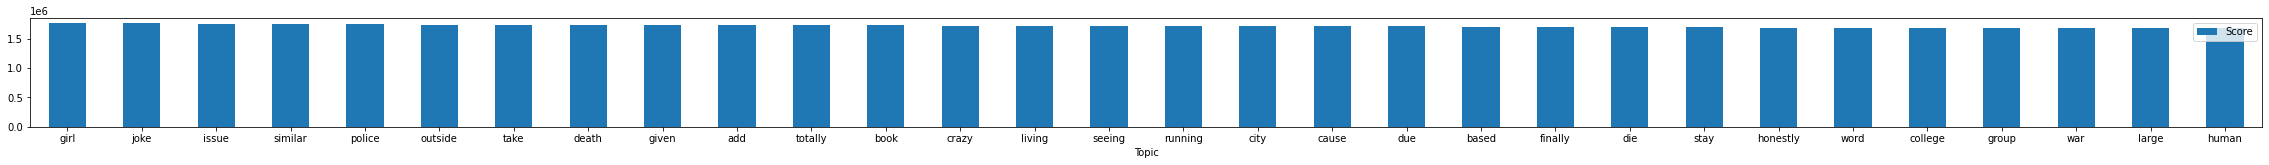

In [ ]:
print( "Highest-Scored 10 Topics")

req3_df['Score'] = pd.to_numeric(req3_df['Score'])
top_scores = req3_df.iloc[370:400, :]

# Click on graph to view in good proportions
ax = top_scores.plot.bar(x='Topic', y='Score', rot=0, figsize=(40, 2))

We have taken only 30 of the 600 top-scored topics we got to gain some insight. Some words do reflect reasonable topics such as *girl, jokes, issue, war, books, police, city, college, and human.* A few are common stopwords like *honestly, large, and finally.*

## Creative Requirement

### Analysis of Percentage of Edited Comments per User


In [ ]:
path = "/content/drive/MyDrive/BigData/Proj1/CreativeRequirements/output/part-00000"

f = open(path, "r")
Lines = f.readlines()

data = []

for line in Lines: 
    lst = line.strip().split("\t")
    data.append(lst)

# Create the pandas DataFrame
df = pd.DataFrame(data, columns = ['UserName', 'EditedComments', 'TotalComments'])

In [ ]:
df['EditedComments'] = pd.to_numeric(df['EditedComments'])
df['TotalComments'] = pd.to_numeric(df['TotalComments'])

In [ ]:
df[df['EditedComments'] > 0]

,UserName,EditedComments,TotalComments


  Here, I have been trying to get the percentage of edited comments for each user; reflecting how often they edit their comments. This mapreduce job has run on the entire dataset. And as we can see here, **There is no edited comments in the dataset.** However, we now have a list of all **2,512,122 users** and their comments' count.

So, let's visualize this,

In [ ]:
df.drop('EditedComments', axis=1, inplace=True)
sorted_df = df.sort_values(by=['TotalComments'], ascending=False)
sorted_df

,UserName,TotalComments
94919,AutoModerator,233144
833527,PoliticBot,61889
1299468,autowikibot,22599
1127393,TweetPoster,16325
1675357,havoc_bot,14186
...,...,...
941694,Serenity87,1
2008114,nerostorm,1
1550449,egbertincognito,1
1550448,egbertian413,1


In [ ]:
df1 = sorted_df[sorted_df['TotalComments'] == 1]
print("Number of Users who commented only ONCE is", len(df1.index), "Users")
df2 = sorted_df.head(20)
print("\n\nTop and Last Twenty Comments' Counts' Users")
display(pd.concat([
    df1.head(20).reset_index(drop=1).add_suffix('_1'),
    df2.reset_index(drop=1).add_suffix('_2')
  ], axis=1).fillna(''))

Number of Users who commented only ONCE is 666047 Users


Top and Last Twenty Comments' Counts' Users


,UserName_1,TotalComments_1,UserName_2,TotalComments_2
0,Damianf60,1,AutoModerator,233144
1,ThisIsNoobsRus,1,PoliticBot,61889
2,DamBones,1,autowikibot,22599
3,snowtime33,1,TweetPoster,16325
4,Dallez,1,havoc_bot,14186
5,smkjuan,1,Doctor-Kitten,13830
6,somethingindifferent,1,MTGCardFetcher,12306
7,somerandomdudepls,1,imgurtranscriber,10302
8,Dalers08,1,RPBot,10014
9,DSelitskiy,1,Marvelvsdc00,9090


Top commenter is **AutoModerator**; a famous and helpful bot on Reddit which makes sense. One noticable thing about the top commenters is that most (if not all) are bots. This changes our prespective on the data since some of the analysis we made was based on the idea that the commenters are human users. We have to consider identifying and removing their comments once they are irrelevant to the analysis we are doing. One idea would be to use the **[I am a bot]** phrase most bots use. However, there are no standards for the use of bots on Reddit; making this task a bit trickier.


### Number of Users per Timestamp [Traffic Analysis]

In this requirement, we decided to **investigate the traffic of commenting users per timestamp to check when are the busiest times**. This map-reduce job has been run on the entire dataset to gather insight.

Dataset has an attribute named `created_utc` which holds the **Unix epoch** when the comment has been created. 

One user is counted only one time per timestamp since we are trying to figure out how many users are commenting; not the number of comments.

As follows, we turn the epoch to a readable form for the human eyes. And, we dump the data into a dataframe for easier analysis.

In [6]:
import datetime

# Read output file from drive
path_to_reqCT_output = "/content/drive/MyDrive/BigData/Proj1/CreativeRequirements/TrafficTracking/output/part-00000"
f = open(path_to_reqCT_output, "r")

Lines = f.readlines()

data = []

for line in Lines: 
    myLine = line.strip().split('|')
    time_stmp = datetime.datetime.fromtimestamp(int(myLine[0].strip()))
    topics = len(ast.literal_eval(myLine[1].strip()))
    data.append([time_stmp.date(), time_stmp.time(), topics])

# Put in a dataframe
reqCT_df = pd.DataFrame(data, columns = ['Date', 'Time', 'Number of Users'])

In [7]:
reqCT_df

,Date,Time,Number of Users
0,2015-01-01,00:00:00,10
1,2015-01-01,00:00:01,18
2,2015-01-01,00:00:02,13
3,2015-01-01,00:00:03,15
4,2015-01-01,00:00:04,16
...,...,...,...
2678204,2015-01-31,23:59:55,24
2678205,2015-01-31,23:59:56,20
2678206,2015-01-31,23:59:57,25
2678207,2015-01-31,23:59:58,24


Off to a good start, the results show that this dataset has been collected over the course of ***one month*** which is the month of `January-2015`. 

In [55]:
reqCT_df['Date'] = pd.to_datetime(reqCT_df.Date, format='%Y-%m-%d')
reqCT_df['Time'] = pd.to_datetime(reqCT_df.Time, format='%H:%M:%S')

In [41]:
# ----- Counting No. of users per Day -----
dates = list(np.arange(1, 32))
count_usrs = []
for i in range(0, 31):
  x = reqCT_df[reqCT_df["Date"].dt.day == dates[i]]
  count_usrs.append( x.sum(axis=0).values[0] )

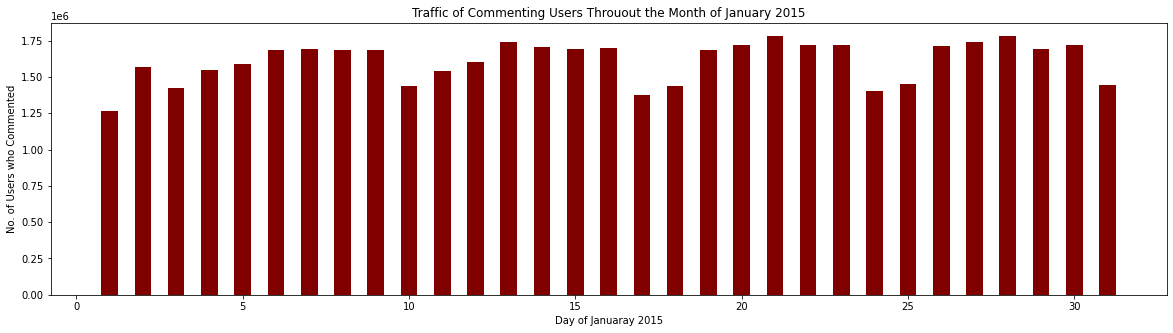

Day with Minimum Traffic is: 1
Day with Maximum Traffic is: 21


In [61]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (20, 5))
 
plt.bar(dates, count_usrs, color ='maroon', width = 0.5)
 
plt.xlabel("Day of Januaray 2015")
plt.ylabel("No. of Users who Commented")
plt.title("Traffic of Commenting Users Throuout the Month of January 2015")
plt.show()

min_day = np.argmin(count_usrs)
print("Day with Minimum Traffic is:", min_day + 1)
max_day = np.argmax(count_usrs)
print("Day with Maximum Traffic is:", max_day + 1)

We observe how the least busy day is the first of January [new year's eve] which makes sense considering all the celebrations and outings that night.
Buisiest day has been shown to be 21 of January; towards the end of the month.

In [56]:
# ----- Counting No. of users per Hour ----- #

times = list(range(24))
count_usrs_time = []
for i in times:
  x = reqCT_df[reqCT_df["Time"].dt.hour == times[i]]
  count_usrs_time.append( x.sum(axis=0).values[0] )

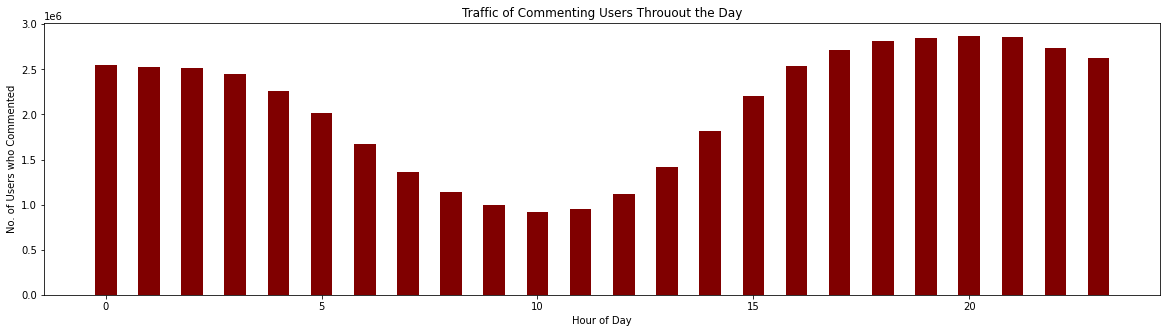

Hour with Minimum Traffic is: 10
Hour with Maximum Traffic is: 20


In [60]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (20, 5))
 
plt.bar(times, count_usrs_time, color ='maroon', width = 0.5)
 
plt.xlabel("Hour of Day")
plt.ylabel("No. of Users who Commented")
plt.title("Traffic of Commenting Users Throuout the Day")
plt.show()

min_hr = np.argmin(count_usrs_time)
print("Hour with Minimum Traffic is:", min_hr)
max_hr = np.argmax(count_usrs_time)
print("Hour with Maximum Traffic is:", max_hr)

Here, we count how many users have commented at each hour of thw day. The graph seems similar to a normal distribution. As the sun rises, users commenting are lower in number till it hits the lowest at 10 AM. This is reasonable considering people start being busy with their day around this time.

Then, the number of users commenting gradually increases till the site is buisiest at 8:00 PM. Also reasonable as this is the time most people's work/school day is over and they can start browsing and commenting. 

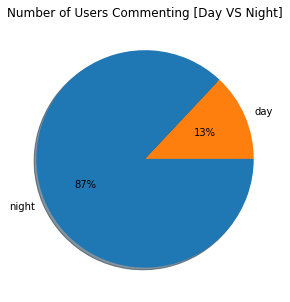

In [100]:
sumo = sum(count_usrs_time)
my_new_list = [i /sumo for i in count_usrs_time]
plt.figure(figsize = (20, 5))
plt.pie([sum(my_new_list, 12), 100 - sum(my_new_list, 12)], labels = ['day', 'night'], shadow = True, colors=["#ff7f0e", "#1f77b4"], autopct='%.0f%%')
plt.title('Number of Users Commenting [Day VS Night]')
plt.show()


# Challenges and Optimization

> First challenge faced was dealing with the huge amount of data we have. Reading data, testing the code, and making sure it scales well were all challenges that had to be considered. We've dealt with this by taking samples of 10, 20, 100, 100K, and a million records. These files were used to test the map-reduce jobs before running them on the *entire dataset*.




>In the third requirement, we faced the issue of the code running for way too long even when experimenting on half of the data. So, another challenge was using `NLTK Library` on the dataset. It did not scale well as the number of words, needing to be checked, increased. A solution was to:
* Seperate the map-reduce job into two jobs; one that performs a count of the scores of each word in the comments. The other gets the top and lowest scored X topics.
*  Use a heap queue in the second job to maintain the top and lowest X scored topics. This has improved the performance remarkably due to the fast insertion sort.

> Running analysis jobs on the entire dataset on Colab helped improve our results greatly. It provided us with some insights about what to expect, what is or isn't in the dataset, and what underlying assumptions are wrong.

# Design of Code

Each Requirement has either a README file or well-commented parts explaining our coding choices. In general, we aimed for efficient performance; especially with the `NLTK` library part where a lot of time was wasted on checking repeated words or phrases.